# Modelos de media móvil (MA)

Veremos cómo usar la función de autocorrelación (ACF) para estimar el orden (q) de un modelo MA y además veremos cómo usar StatsForecast y statsmodels para construir un modelo MA.

## 1. Lectura y exploración del set de datos

Vamos a extender el ejemplo de estimación de temperatura a un set de datos con 100 registros (1 por día).

Comencemos cargando las librerías necesarias y leyendo el set de datos:

In [1]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import ARIMA
import statsmodels.api as sm

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

In [2]:
# El set de datos
df = pd.read_csv('datos/serie_estacionaria_MA.csv')
df

,unique_id,ds,y
0,temperatura,1,21.2
1,temperatura,2,20.8
2,temperatura,3,18.8
3,temperatura,4,21.2
4,temperatura,5,21.6
...,...,...,...
95,temperatura,96,18.8
96,temperatura,97,20.0
97,temperatura,98,20.0
98,temperatura,99,18.8


Y hagamos un gráfico de la Serie en el tiempo así como de su valor medio:

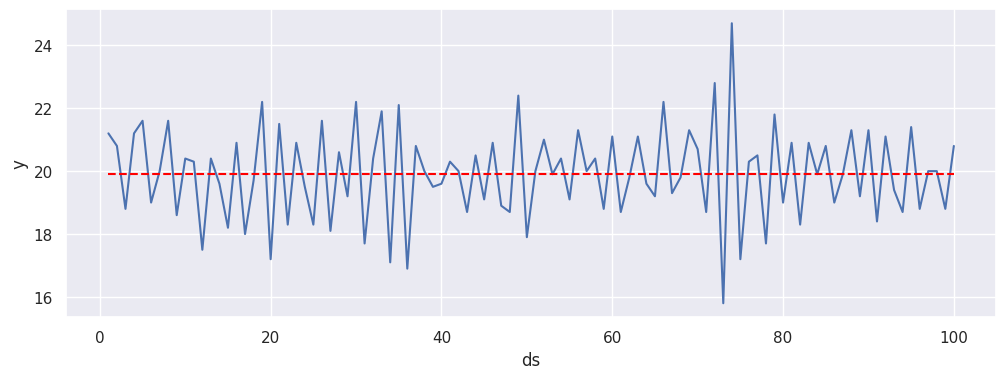

In [4]:
sns.lineplot(df, x="ds", y="y")
plt.hlines(df["y"].mean(), xmin=df["ds"].min(), xmax=df["ds"].max(), color='red', linestyle='--')

**Observaciones:**
- Es una Serie estacionaria, por lo cual podríamos usar un modelo MA (o incluso un modelo AR).
- ¿Cuál sería el tipo de modelo más adecuado en este caso?

La respuesta a lo anterior está en la ACF.

## 2. La ACF y el orden (q) de un modelo MA

En la lección anterior vimos que:

- Si los coeficientes de la ACF decrecen lentamente
- Pero los coeficientes de la PACF caen abruptamente a cero

Entonces esto es una clara indicación de que el modelo AR es el más adecuado para la Serie.

Sin embargo, **en los modelos MA es la ACF la que contiene información relevante para determinar si el modelo adecuado es precisamente MA y cuál sería su orden**. Entendamos por qué.

### 2.1. Características de la ACF para una Serie MA

Supongamos una simple Serie que podemos representar como un modelo MA(1):

$$y_t = c + \epsilon_t + \theta_1 \epsilon_{t-1}$$

A partir de esta expresión obtengamos una expresión para $y_{t-1}$:

$$y_{t-1} = c + \epsilon_{t-1} + \theta_1 \epsilon_{t-2}$$

$$y_{t-2} = c + \epsilon_{t-2} + \theta_1 \epsilon_{t-3}$$

Y ahora respondamos a estas preguntas:

**1. ¿Están $y_t$ y $y_{t-1}$ correlacionadas?**

La respuesta es SÍ. Basta con observar que ambas tienen en común el término $\epsilon_{t-1}$.

Así, **al calcular la ACF con un lag=1 veremos un valor alto de correlación**.

**2. ¿Están $y_t$ y $y_{t-2}$ correlacionadas?**

La respuesta es NO. Basta con observar que no tienen en común ningún término.

Así, **al calcular la ACF con un lag=2 no veremos prácticamente correlación**. Y de hecho esto ocurre si calculamos correlaciones con lags de 3, 4 o más.

Conclusión de este ejemplo:
- La serie presenta un único pico en ACF(1) y después de esto **decae abruptamente a cero**
- Y esto es consistente con el modelo usado: MA de orden q=1 (MA(1))

### 2.2. Estimación del orden (q) de un modelo MA usando la ACF

Así que a partir de este ejemplo podemos generalizar. **Para saber si podemos modelar la serie con MA observamos la ACF** y:
- Si tiene **caídas abruptas** muy probablemente el modelo más adecuado será MA
- Y el orden "q" del modelo estará determinado por la **cantidad de coeficientes en la ACF diferentes de cero**

Veamos esto de forma práctica para la Serie de tiempo que estamos analizando.

Hagamos un gráfico de la Serie y de su ACF:

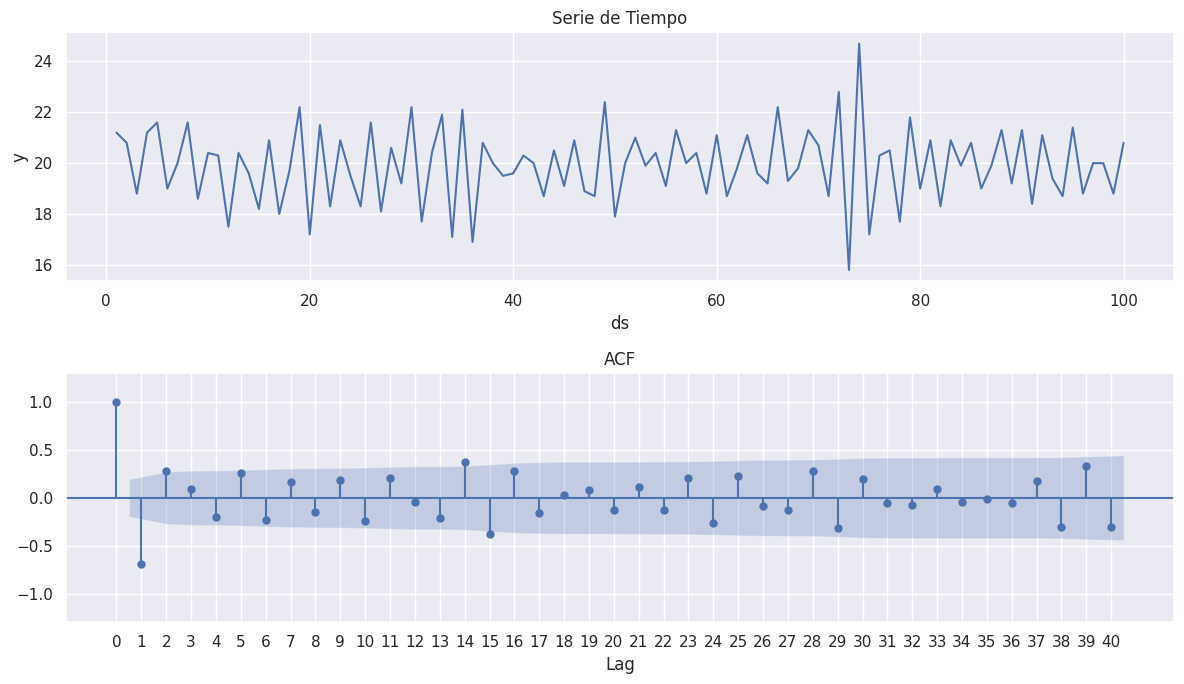

In [5]:
# Grilla de 2x1
fig, axs = plt.subplots(2,1, figsize=(12,7))

# Serie de tiempo
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie de Tiempo')

# ACF
LAGS = 40
plot_acf(df["y"],
        adjusted=True,
        alpha=0.05, # Intervalo de confianza del 95%
        lags = LAGS,
        ax = axs[1]);
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_ylim([-1.3, 1.3])
axs[1].grid(True)

fig.tight_layout()

**Observaciones:**
- ¡La ACF tiene un corte abrupto después del segundo lag!
- Así que un modelo MA(2) puede ser el más adecuado en este caso

## 3. Entrenamiento del modelo MA

Veamos cómo entrenar el modelo usando tanto StatsForecast como la librería statsmodels.

En ambos casos construiremos un modelo MA(p=0, d=0, q=2). Veamos primero el modelo en StatsForecast:

In [6]:
# Instancia del modelo
models = [ARIMA(order=(0, 0, 2), alias="MA(2)")]
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Entrenar con fit
sf.fit(df)

StatsForecast(models=[MA(2)])

Una vez entrenado el modelo podemos extraer toda su información accediendo al atributo "fitted_":

In [7]:
modelo_sf = sf.fitted_[0][0].model_
modelo_sf

{'coef': {'ma1': np.float64(-1.0556452775499483),
  'ma2': np.float64(0.7688710284765867),
  'intercept': np.float64(19.908924990880788)},
 'sigma2': np.float64(0.834962652867968),
 'var_coef': array([[ 5.07106378e-03, -2.76130014e-03, -1.08941372e-04],
        [-2.76130014e-03,  3.49196719e-03, -8.75626565e-05],
        [-1.08941372e-04, -8.75626565e-05,  4.14593300e-03]]),
 'mask': array([ True,  True,  True]),
 'loglik': np.float64(-132.4670683187351),
 'aic': np.float64(272.9341366374702),
 'arma': (0, 2, 0, 0, 1, 0, 0),
 'residuals': array([ 7.84916979e-01,  1.49723471e+00,  1.85600290e-01,  4.65673607e-01,
         1.91570736e+00,  7.90899250e-01, -4.36481252e-01,  6.29218697e-01,
        -3.13487071e-01, -3.07255550e-01,  3.00960206e-01, -1.84313892e+00,
        -1.67803214e+00, -6.70731747e-01, -1.12822324e+00,  3.11779643e-01,
        -7.14265998e-01, -1.19948947e+00,  1.57103147e+00, -1.29425543e-01,
         2.47762707e-01, -1.24722292e+00, -5.15849874e-01,  4.88934431e-03,


Y veamos los parámetros del modelo:

In [8]:
# Extraer los parámetros del modelo entrenado (c, theta_1 y theta_2)
params = modelo_sf['coef']

# Imprimir
for name, value in params.items():
    print(f"Parametro {name:10} : {value:.4f}")


Parametro ma1        : -1.0556
Parametro ma2        : 0.7689
Parametro intercept  : 19.9089


Y podemos observar que el $\theta_1$ es negativo mientras que $\theta_2$ es negativo, lo cual coincide perfectamente con lo observado en la PACF de la Serie.

Así que este modelo $MA(2)$ es de la forma:

$$y_t = 19.8658 + \epsilon_t - 0.9664\epsilon_{t-1} + 0.8686\epsilon_{t-2}$$

Veamos cómo hacer lo mismo pero con "statsmodels":

In [9]:
# orden: (p, d, q)
modelo_sm = sm.tsa.ARIMA(df['y'], order=(0, 0, 2))
resultados = modelo_sm.fit()

# Con statsmodels es muy sencillo acceder a la información del modelo
print(resultados.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -132.467
Date:                Sat, 02 May 2026   AIC                            272.934
Time:                        20:14:51   BIC                            283.355
Sample:                             0   HQIC                           277.152
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9089      0.065    307.865      0.000      19.782      20.036
ma.L1         -1.0557      0.071    -14.851      0.000      -1.195      -0.916
ma.L2          0.7689      0.084      9.177      0.0

Y con cualquiera de los dos modelos podemos hacer un análisis de residuales.

Recordemos que si el modelo es:

$$y_t = 19.9089 + \epsilon_t - 0.9664\epsilon_{t-1} + 0.8686\epsilon_{t-2}$$

los residuales serán el componente que no logra capturar el modelo, es decir:

$$residuales = \epsilon_t$$

Idealmente estos residuales deberían ser "pequeños" (comparados con los niveles originales de la Serie) y deberían tener una media cercana a cero, así como una ACF que no exhiba ningún patrón específico:

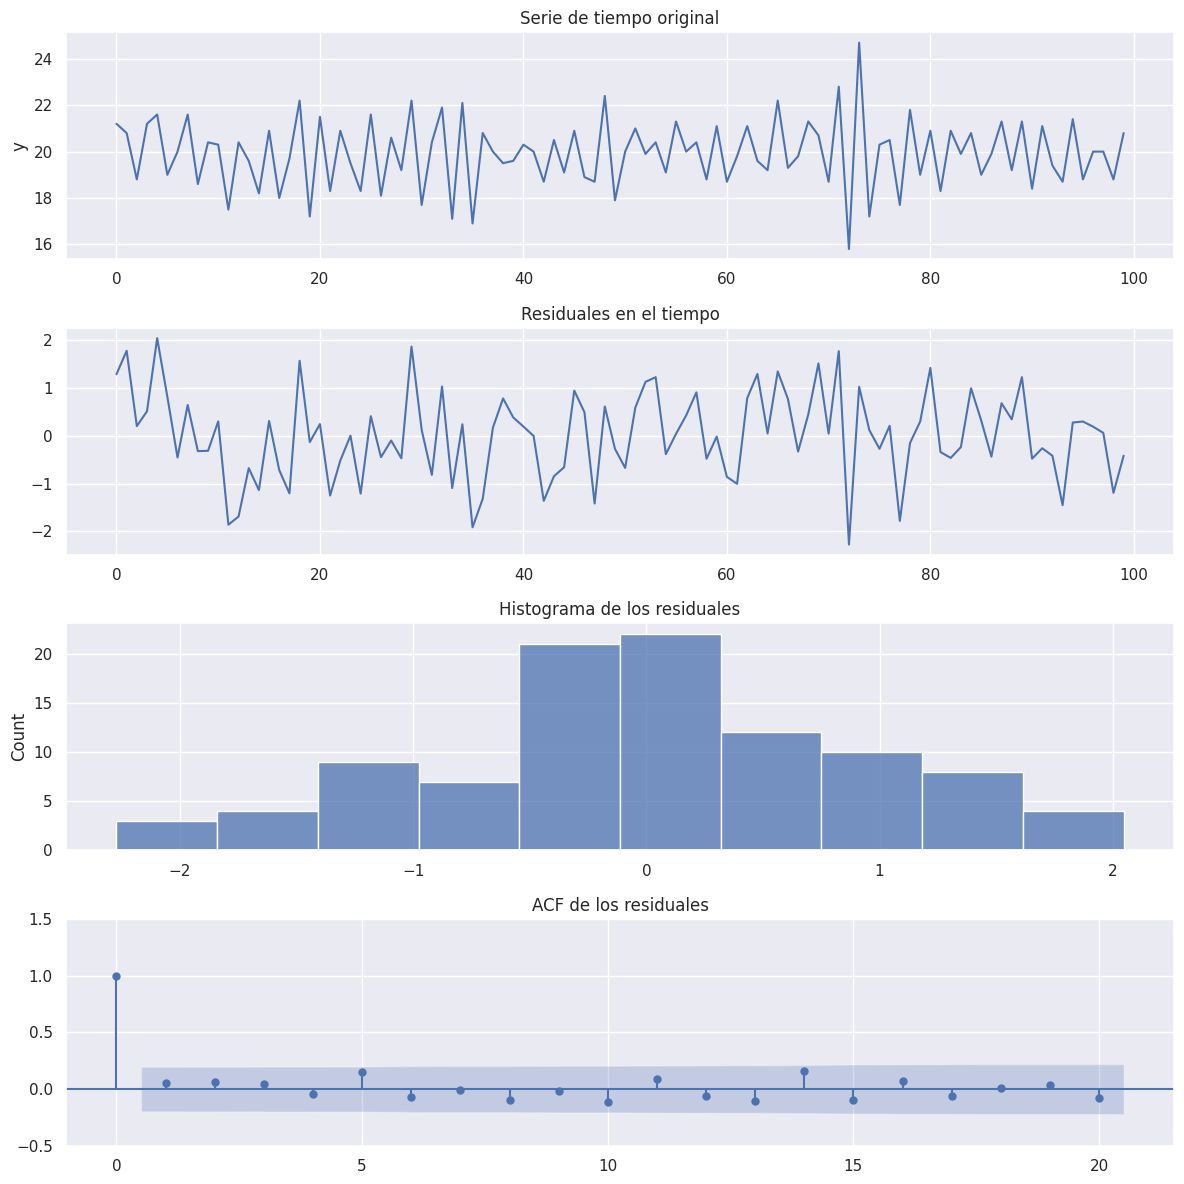

In [10]:
# Extraer residuales (de cualquiera de los dos modelos)
#res = modelo_sf['residuals']
res = resultados.resid.values

# Graficar serie, residuales en el tiempo, histograma y ACF de dichos residuales
fig, axs = plt.subplots(4,1,figsize=(12,12))

sns.lineplot(df["y"], ax=axs[0])
axs[0].set_title('Serie de tiempo original')

sns.lineplot(res, ax=axs[1])
axs[1].set_title('Residuales en el tiempo')

sns.histplot(res, ax=axs[2])
axs[2].set_title('Histograma de los residuales')

plot_acf(res, ax=axs[3])
axs[3].set_title('ACF de los residuales')
axs[3].set_ylim([-0.5, 1.5])

plt.tight_layout();

**Observaciones:**
- Vemos que los residuales son casi ideales: media cercana a cero, no exhiben patrones en la ACF
- Pero hay un ligero sesgo en el histograma hacia una media inferior a cero. Esto quiere decir que si $residuales = y_t - \hat{y_t}$, entonces en promedio el modelo MA(2) tiende a sobre-estimar ligeramente los valores en la Serie

## 4. Generación de pronósticos con el modelo AR

Podemos usar StatsForecast y la misma lógica que vimos en la lección anterior para así generar pronósticos.

Supongamos que generaremos un pronóstico a 10 horas y dibujaremos la serie original, el pronóstico puntual y el intervalo de predicción del 90%:

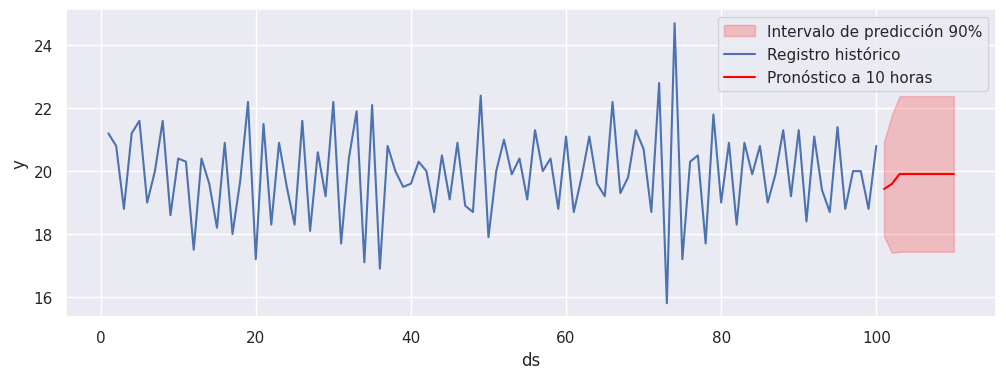

In [11]:
# Instancia modelo AR(2)
models = [ARIMA(order=(0, 0, 2), alias="MA(2)")] # p=0, d=0, q=2
sf = StatsForecast(models=models,
                freq=1, # La frecuencia de la serie es simplemente un entero
                )

# Pronóstico a h=10 horas
fc = sf.forecast(df=df,
                h=10,
                level=[90]
)

# Gráfico serie original, pronóstico e intervalo de predicción
fig, ax = plt.subplots()
plt.fill_between(x=fc["ds"],
                y1 = fc['MA(2)-lo-90'],
                y2 = fc['MA(2)-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90%');
sns.lineplot(df, x="ds", y="y", label='Registro histórico');
sns.lineplot(fc, x="ds", y="MA(2)", color='red', label='Pronóstico a 10 horas');

Y acá hay un resultado interesante, los pronósticos tienen valores diferentes sólo para los dos primeros valores en la ventana de pronóstico (t+1, t+2) y después de esto se estabilizan al valor de la media:

In [12]:
fc

,unique_id,ds,MA(2),MA(2)-lo-90,MA(2)-hi-90
0,temperatura,101,19.431186,17.928180,20.934192
1,temperatura,102,19.590101,17.404590,21.775613
2,temperatura,103,19.908925,17.436697,22.381153
3,temperatura,104,19.908925,17.436697,22.381153
4,temperatura,105,19.908925,17.436697,22.381153
5,temperatura,106,19.908925,17.436697,22.381153
6,temperatura,107,19.908925,17.436697,22.381153
7,temperatura,108,19.908925,17.436697,22.381153
8,temperatura,109,19.908925,17.436697,22.381153
9,temperatura,110,19.908925,17.436697,22.381153


Esto se debe a que el modelo por ser de orden 2 sólo tiene en cuenta las últimas dos variaciones del error que harán que se aleje de la media, cuando estas variaciones expiran (para t+3, t+4, ...) los pronósticos **regresan a la media estimada para el modelo (19.9089)**